# Hotel Review Sentiment Classification

## Small-Dataset NLP Case Study

This project classifies TripAdvisor hotel reviews as **positive** or **negative** using classical natural language processing and machine-learning techniques.

The original dataset contains **109 reviews** with a 1–5 star rating. Because this is a small dataset, the goal is not to claim production-level performance. Instead, the project demonstrates a careful end-to-end text-classification workflow and makes the limitations of the data explicit.

### Skills demonstrated

- text-data inspection and cleaning
- sentiment-label construction
- class-imbalance awareness
- CountVectorizer and TF-IDF
- Logistic Regression
- Multinomial Naive Bayes
- SGD linear classifier
- stratified cross-validation
- accuracy, balanced accuracy, precision, recall, and macro F1
- confusion-matrix analysis
- feature interpretation
- error analysis


## 1. Problem Definition

The dataset provides review text and a 1–5 star rating.

For this binary sentiment project:

- **Ratings 1–2 → Negative**
- **Rating 3 → Neutral and excluded from binary modeling**
- **Ratings 4–5 → Positive**

Removing 3-star reviews avoids forcing genuinely mixed or neutral reviews into a positive/negative label.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 140)


## 2. Load and Inspect the Data

The notebook expects `tripadvisor_hotel_reviews.csv` to be in the same folder as the notebook.


In [2]:
DATA_PATH = Path("tripadvisor_hotel_reviews.csv")

data = pd.read_csv(DATA_PATH)

print("Dataset shape:", data.shape)
display(data.head())


Dataset shape: (109, 2)


,Review,Rating
0,"nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, ...",4
1,"ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website descr...",2
2,nice rooms not 4* experience hotel monaco seattle good hotel n't 4* level.positives large bathroom mediterranean suite comfortable bed p...,3
3,"unique, great stay, wonderful time hotel monaco, location excellent short stroll main downtown shopping area, pet friendly room showed n...",5
4,"great stay great stay, went seahawk game awesome, downfall view building did n't complain, room huge staff helpful, booked hotels websit...",5


In [3]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  109 non-null    object
 1   Rating  109 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


In [4]:
quality_check = pd.Series(
    {
        "rows": len(data),
        "missing_reviews": data["Review"].isna().sum(),
        "missing_ratings": data["Rating"].isna().sum(),
        "duplicate_reviews": data["Review"].duplicated().sum(),
    },
    name="value",
)

quality_check


rows                 109
missing_reviews        0
missing_ratings        0
duplicate_reviews      0
Name: value, dtype: int64

## 3. Rating Distribution

Before converting ratings into sentiment labels, inspect how many reviews belong to each rating.


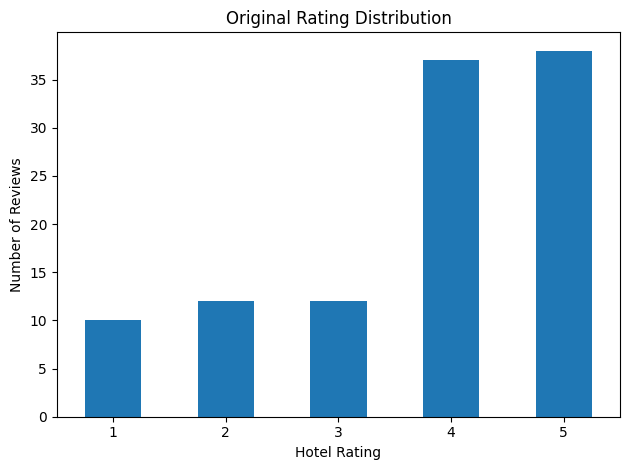

Rating
1    10
2    12
3    12
4    37
5    38
Name: count, dtype: int64

In [5]:
rating_counts = data["Rating"].value_counts().sort_index()

ax = rating_counts.plot(kind="bar", rot=0)
ax.set_title("Original Rating Distribution")
ax.set_xlabel("Hotel Rating")
ax.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

rating_counts


## 4. Create Binary Sentiment Labels

Three-star reviews are removed because they are the most natural neutral/mixed category.

This leaves a smaller dataset, but the target becomes clearer.


In [6]:
model_data = data.loc[data["Rating"] != 3, ["Review", "Rating"]].copy()

model_data["sentiment"] = np.where(
    model_data["Rating"] >= 4,
    "positive",
    "negative",
)

model_data["target"] = model_data["sentiment"].map(
    {"negative": 0, "positive": 1}
)

print("Rows used for binary classification:", len(model_data))
display(model_data.head())


Rows used for binary classification: 97


,Review,Rating,sentiment,target
0,"nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, ...",4,positive,1
1,"ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website descr...",2,negative,0
3,"unique, great stay, wonderful time hotel monaco, location excellent short stroll main downtown shopping area, pet friendly room showed n...",5,positive,1
4,"great stay great stay, went seahawk game awesome, downfall view building did n't complain, room huge staff helpful, booked hotels websit...",5,positive,1
5,love monaco staff husband stayed hotel crazy weekend attending memorial service best friend husband celebrating 12th wedding anniversary...,5,positive,1


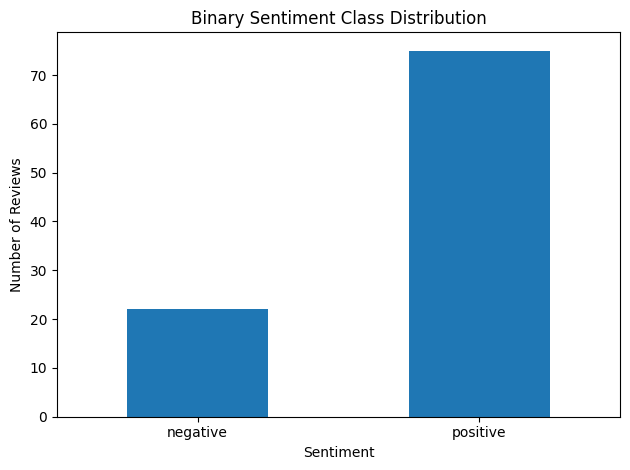

sentiment
negative    22
positive    75
Name: count, dtype: int64

In [7]:
sentiment_counts = model_data["sentiment"].value_counts().reindex(
    ["negative", "positive"]
)

ax = sentiment_counts.plot(kind="bar", rot=0)
ax.set_title("Binary Sentiment Class Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

sentiment_counts


### Important class-imbalance note

The positive class is much larger than the negative class. A model that predicts the majority class every time can therefore achieve deceptively high accuracy.

For that reason, this project reports:

- **Accuracy** — overall proportion correct
- **Balanced accuracy** — average recall across the two classes
- **Macro F1** — gives each class equal importance regardless of class size

Macro F1 and balanced accuracy are especially important here.


In [8]:
majority_class = model_data["target"].mode().iloc[0]
majority_predictions = np.full(len(model_data), majority_class)

baseline = pd.Series(
    {
        "accuracy": accuracy_score(model_data["target"], majority_predictions),
        "balanced_accuracy": balanced_accuracy_score(
            model_data["target"], majority_predictions
        ),
        "f1_macro": f1_score(
            model_data["target"],
            majority_predictions,
            average="macro",
            zero_division=0,
        ),
    },
    name="Majority-class baseline",
)

baseline.round(3)


accuracy             0.773
balanced_accuracy    0.500
f1_macro             0.436
Name: Majority-class baseline, dtype: float64

## 5. Light Text Inspection

The reviews are already mostly lowercase and stripped of much of their punctuation. Rather than aggressively removing words, this project lets the vectorizers handle tokenization and lowercasing.

This also preserves useful sentiment cues such as **not**, which can be lost by overly aggressive stop-word removal.


In [9]:
model_data["word_count"] = model_data["Review"].str.split().str.len()

model_data["word_count"].describe()


count     97.000000
mean      85.525773
std       57.788244
min       14.000000
25%       43.000000
50%       71.000000
75%      111.000000
max      250.000000
Name: word_count, dtype: float64

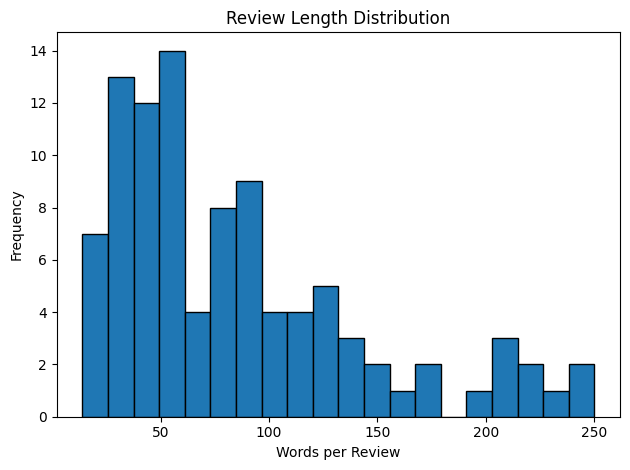

In [10]:
ax = model_data["word_count"].plot(kind="hist", bins=20, edgecolor="black")
ax.set_title("Review Length Distribution")
ax.set_xlabel("Words per Review")
plt.tight_layout()
plt.show()


## 6. Model Comparison Strategy

With only 97 clearly labeled reviews, a single train/test split would make the result depend heavily on which few reviews happened to land in the test set.

Instead, the project uses **5-fold stratified cross-validation**:

1. Divide the data into five folds while preserving class proportions.
2. Train on four folds.
3. Evaluate on the remaining fold.
4. Repeat until every fold has served as validation data.

All text vectorization happens **inside each pipeline**, so vocabulary and TF-IDF weights are learned only from the training portion of each fold. This prevents data leakage.


In [11]:
X = model_data["Review"]
y = model_data["target"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

models = {
    "Count + Naive Bayes": Pipeline(
        [
            (
                "vectorizer",
                CountVectorizer(
                    ngram_range=(1, 2),
                    min_df=2,
                ),
            ),
            ("classifier", MultinomialNB()),
        ]
    ),
    "TF-IDF + Logistic Regression": Pipeline(
        [
            (
                "vectorizer",
                TfidfVectorizer(
                    ngram_range=(1, 2),
                    min_df=2,
                    sublinear_tf=True,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "TF-IDF + SGD Classifier": Pipeline(
        [
            (
                "vectorizer",
                TfidfVectorizer(
                    ngram_range=(1, 2),
                    min_df=2,
                    sublinear_tf=True,
                ),
            ),
            (
                "classifier",
                SGDClassifier(
                    loss="hinge",
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

models


{'Count + Naive Bayes': Pipeline(steps=[('vectorizer', CountVectorizer(min_df=2, ngram_range=(1, 2))),
                 ('classifier', MultinomialNB())]),
 'TF-IDF + Logistic Regression': Pipeline(steps=[('vectorizer',
                  TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                  sublinear_tf=True)),
                 ('classifier',
                  LogisticRegression(class_weight='balanced', max_iter=2000,
                                     random_state=42))]),
 'TF-IDF + SGD Classifier': Pipeline(steps=[('vectorizer',
                  TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                  sublinear_tf=True)),
                 ('classifier',
                  SGDClassifier(class_weight='balanced', random_state=42))])}

## 7. Cross-Validated Model Results

Each model is evaluated on the same five stratified folds.

Because the dataset is small, the standard deviation across folds is shown alongside the average score. Large variation would be a warning that the estimate is unstable.


In [12]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}

result_rows = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
    )

    row = {"model": model_name}

    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    result_rows.append(row)

results = (
    pd.DataFrame(result_rows)
    .sort_values("f1_macro_mean", ascending=False)
    .reset_index(drop=True)
)

results.round(3)


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
0,Count + Naive Bayes,0.897,0.045,0.793,0.075,0.913,0.074,0.793,0.075,0.829,0.078
1,TF-IDF + Logistic Regression,0.887,0.049,0.773,0.083,0.908,0.073,0.773,0.083,0.809,0.085
2,TF-IDF + SGD Classifier,0.845,0.048,0.823,0.044,0.796,0.058,0.823,0.044,0.796,0.052


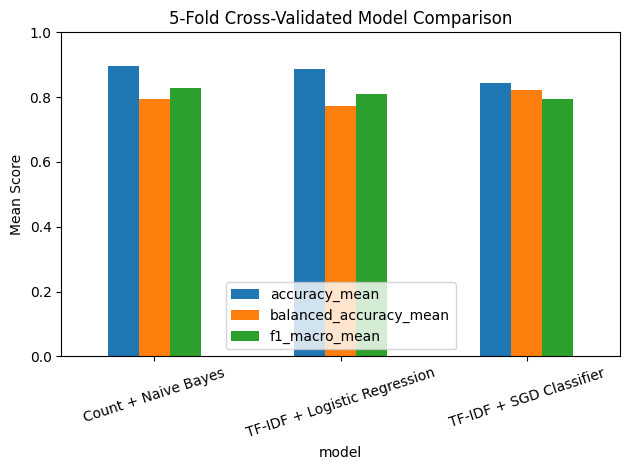

In [13]:
plot_data = results.set_index("model")[
    ["accuracy_mean", "balanced_accuracy_mean", "f1_macro_mean"]
]

ax = plot_data.plot(kind="bar", rot=18)
ax.set_title("5-Fold Cross-Validated Model Comparison")
ax.set_ylabel("Mean Score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 8. Select the Best Model

The model with the highest **mean macro F1-score** is selected.

Macro F1 is used instead of raw accuracy because the dataset contains far more positive than negative reviews.


In [14]:
best_model_name = results.loc[0, "model"]
best_model = models[best_model_name]

print("Best model by cross-validated macro F1:", best_model_name)


Best model by cross-validated macro F1: Count + Naive Bayes


## 9. Out-of-Fold Predictions and Confusion Matrix

`cross_val_predict` produces a prediction for each review from a model that was **not trained on that review**.

That gives us one out-of-fold prediction per example and allows a more informative confusion matrix than evaluating the same data used for fitting.


In [15]:
oof_predictions = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
)

print(
    classification_report(
        y,
        oof_predictions,
        target_names=["negative", "positive"],
        digits=3,
        zero_division=0,
    )
)


              precision    recall  f1-score   support

    negative      0.929     0.591     0.722        22
    positive      0.892     0.987     0.937        75

    accuracy                          0.897        97
   macro avg      0.910     0.789     0.829        97
weighted avg      0.900     0.897     0.888        97



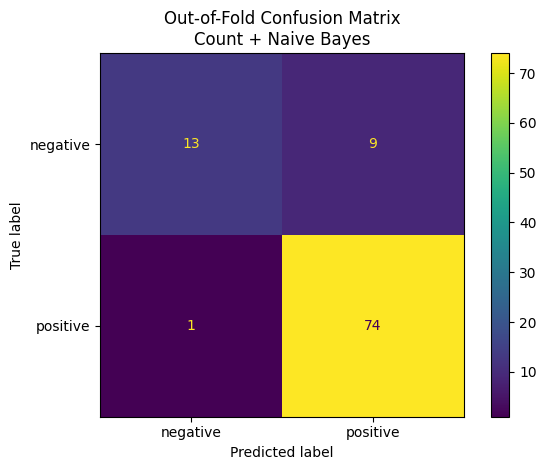

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y,
    oof_predictions,
    display_labels=["negative", "positive"],
    values_format="d",
)

plt.title(f"Out-of-Fold Confusion Matrix\n{best_model_name}")
plt.tight_layout()
plt.show()


## 10. Error Analysis

Looking at mistakes is more useful than reporting one score.

The table below shows reviews the selected model misclassified during cross-validation.


In [17]:
error_analysis = model_data[
    ["Review", "Rating", "sentiment"]
].copy()

error_analysis["predicted_sentiment"] = np.where(
    oof_predictions == 1,
    "positive",
    "negative",
)

errors = error_analysis.loc[
    error_analysis["sentiment"] != error_analysis["predicted_sentiment"]
].copy()

print("Out-of-fold errors:", len(errors))
display(errors)


Out-of-fold errors: 10


,Review,Rating,sentiment,predicted_sentiment
10,"poor value stayed monaco seattle july, nice hotel priced 100- 150 night not, hotel takes beating quotient, experience simply average, no...",2,negative,positive
24,"great location need internally upgrade advantage north end downtown seattle great restaurants nearby good prices, rooms need updated lit...",2,negative,positive
32,"noise airconditioner-a standard, arranged stay travel agency unfortunately warwick seattle hotel dissapointment trip, 3 night stay warwi...",1,negative,positive
33,"good location poor cleanliness warwick hotel great location seattle, close shopping pike place seattle centre, really lets hotel cleanli...",2,negative,positive
36,"great value seattle spouse stayed warwick seattle days september, hotel does not disappoint reasonably priced stay downtown area, easy w...",4,positive,negative
45,"great location n't stay long needed place stay seattle prior catching early morning amtrak train portland, looked train station not, dro...",2,negative,positive
65,"hated inn terrible, room-service horrible staff un-welcoming, decor recently updated lacks complete look, managment staff horrible,",1,negative,positive
77,single rooms like hospital rooms single rooms hotel sparse intentional know ugly like trapped hospital white walls sink basin room small...,1,negative,positive
80,"priority award floor, 32 member hilton honors priority award intercontinental chain, use hilton properties chose not pay 250.00 night se...",2,negative,positive
83,"holiday inn, 1st time seattle delayed anniversary trip wanted stay nicer hotels room reminded holiday inn level hotel, plain room extra ...",2,negative,positive


### What the errors can tell us

With a dataset this small, individual reviews can noticeably affect the metrics. Misclassifications may also involve:

- mixed praise and criticism
- negation
- unusual wording or spelling
- reviews that mention both positive and negative experiences
- vocabulary that appears only a few times in the dataset

These are useful places to investigate before deciding whether a more complex model is justified.


## 11. Fit the Selected Model on All Labeled Reviews

After cross-validation is complete, the selected model can be fitted on all 97 labeled examples for demonstration and feature inspection.

This fitted version is **not** used to claim a new test score; the performance estimates above come from cross-validation.


In [18]:
best_model.fit(X, y)

print("Final demonstration model fitted on all labeled reviews.")


Final demonstration model fitted on all labeled reviews.


## 12. Inspect Influential Words and Phrases

The interpretation method depends on which model was selected.

- For Logistic Regression or SGD, larger positive coefficients favor positive sentiment and more negative coefficients favor negative sentiment.
- For Multinomial Naive Bayes, the difference in class log-probabilities is used as an association score.

These features describe what the model learned from this small dataset; they should not be interpreted as universal sentiment rules.


In [19]:
vectorizer = best_model.named_steps["vectorizer"]
classifier = best_model.named_steps["classifier"]
feature_names = vectorizer.get_feature_names_out()

if hasattr(classifier, "coef_"):
    association = classifier.coef_[0]

elif hasattr(classifier, "feature_log_prob_"):
    association = (
        classifier.feature_log_prob_[1]
        - classifier.feature_log_prob_[0]
    )

else:
    association = None

if association is not None:
    negative_idx = np.argsort(association)[:15]
    positive_idx = np.argsort(association)[-15:][::-1]

    feature_table = pd.DataFrame(
        {
            "negative_feature": feature_names[negative_idx],
            "negative_score": association[negative_idx],
            "positive_feature": feature_names[positive_idx],
            "positive_score": association[positive_idx],
        }
    )

    display(feature_table)


,negative_feature,negative_score,positive_feature,positive_score
0,manager,-3.184887,market,3.037689
1,rude,-2.491740,excellent,2.734007
2,response,-2.491740,large,2.244458
3,saying,-2.491740,center,2.244458
4,nonsmoking,-2.309419,friendly,2.103380
5,dingy,-2.309419,loved,2.008070
6,refund,-2.309419,raffles,1.939077
7,says,-2.309419,blocks,1.939077
8,asked desk,-2.309419,distance,1.864969
9,called desk,-2.309419,easy,1.864969


## 13. Demonstrate the Fitted Classifier

The examples below are only a simple demonstration of how the fitted pipeline can accept raw review text and return sentiment predictions.


In [20]:
example_reviews = [
    "The room was clean, comfortable, and the staff were extremely helpful.",
    "The room was dirty, noisy, and the service was terrible.",
    "The location was convenient but the room was disappointing.",
]

example_predictions = best_model.predict(example_reviews)

pd.DataFrame(
    {
        "review": example_reviews,
        "predicted_sentiment": np.where(
            example_predictions == 1,
            "positive",
            "negative",
        ),
    }
)


,review,predicted_sentiment
0,"The room was clean, comfortable, and the staff were extremely helpful.",positive
1,"The room was dirty, noisy, and the service was terrible.",negative
2,The location was convenient but the room was disappointing.,positive


## 14. Limitations and Takeaways

### Limitations

This dataset is intentionally small:

- 109 total reviews
- 97 reviews after removing the 12 neutral 3-star examples
- substantially more positive than negative reviews
- only a small number of negative examples in each cross-validation fold

Because of those limitations, the reported scores should be treated as **illustrative rather than definitive**. A much larger dataset would be needed before making strong claims about real-world generalization.

### Takeaway

Despite the small sample size, this project demonstrates a complete and leakage-aware NLP classification workflow:

- turning ratings into defensible sentiment labels
- recognizing and measuring class imbalance
- comparing multiple text representations and classifiers
- evaluating with stratified cross-validation
- using metrics appropriate for imbalanced data
- examining a confusion matrix and actual mistakes
- interpreting influential features

A future version of the project can apply the same workflow to a substantially larger review dataset.
